# Minería de Datos — Ejercicio Integrador 5
**Dataset:** Online Retail — Transacciones de una tienda online (UCI Machine Learning Repository)

**Nombre:** Gallego Ian 

---
Este ejercicio integrador aplica de forma completa el proceso KDD y el modelo CRISP-DM
sobre el dataset **Online Retail**, que contiene 541.909 transacciones reales de una
tienda de regalos del Reino Unido entre 2010 y 2011. El objetivo es identificar patrones
de compra, segmentar países y detectar registros de baja calidad.

## 1. Aplicación de KDD y CRISP-DM al caso Online Retail

### Descripción del dataset

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `InvoiceNo` | object | Número de factura (prefijo 'C' = devolución) |
| `StockCode` | object | Código de producto |
| `Description` | object | Descripción del artículo |
| `Quantity` | int64 | Unidades vendidas (negativo = devolución) |
| `InvoiceDate` | datetime | Fecha y hora de la transacción |
| `UnitPrice` | float64 | Precio unitario en libras esterlinas (£) |
| `CustomerID` | float64 | ID único del cliente (hay NaN) |
| `Country` | object | País del cliente |

---

### 1.1 Proceso KDD aplicado al caso

| Paso KDD | Acción concreta en Online Retail |
|----------|----------------------------------|
| **Selección** | Cargar el archivo `Online Retail.xlsx` y seleccionar columnas relevantes para el análisis de patrones de compra |
| **Preprocesamiento** | Eliminar filas sin `CustomerID`, descartar transacciones con `Quantity < 0` (devoluciones) y `UnitPrice = 0`, limpiar descripciones nulas |
| **Transformación** | Crear columna `TotalVenta = Quantity × UnitPrice`, extraer mes y año de `InvoiceDate`, convertir `CustomerID` a entero |
| **Minería de Datos** | Segmentar clientes por volumen de compra (RFM), agrupar ventas por país, detectar productos más vendidos |
| **Evaluación / Interpretación** | Identificar los países con mayor facturación, los productos con más devoluciones y los clientes de alto valor |

### 1.2 Correspondencia KDD ↔ CRISP-DM

| Acción del caso | Fase KDD | Fase CRISP-DM |
|-----------------|----------|---------------|
| Definir objetivo: segmentar clientes y maximizar ventas | — | **Business Understanding** |
| Explorar distribuciones de Quantity, UnitPrice y países | Selección | **Data Understanding** |
| Limpiar NaN, negativos y calcular TotalVenta | Preprocesamiento + Transformación | **Data Preparation** |
| Agrupar por país y analizar top productos | Minería de Datos | **Modeling** |
| Validar si los segmentos hallados son accionables para marketing | Evaluación | **Evaluation** |
| Integrar los segmentos al sistema CRM de la tienda | — | **Deployment** |

## 2. Preprocesamiento — Identificación de Problemas y Estrategias

### Problemas detectados en el dataset

| Problema | Columna | Magnitud esperada | Estrategia |
|----------|---------|-------------------|------------|
| Valores faltantes | `CustomerID` | ~135.080 filas (24.9 %) | Eliminar filas sin ID de cliente |
| Valores faltantes | `Description` | ~1.454 filas (0.3 %) | Eliminar filas sin descripción |
| Cantidades negativas (devoluciones) | `Quantity` | Varios miles | Filtrar `Quantity > 0` |
| Precio cero (muestras gratuitas) | `UnitPrice` | Algunos registros | Filtrar `UnitPrice > 0` |
| Tipo incorrecto | `CustomerID` | float64 en lugar de int | Convertir a `Int64` tras limpieza |
| Facturas de devolución | `InvoiceNo` | Empieza con 'C' | Excluir o analizar por separado |

In [1]:
import pandas as pd
import numpy as np
import os

# Ruta relativa al notebook
ruta = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'Online Retail.xlsx')
df = pd.read_excel(ruta)

print('=== Vista del dataset original ===')
print(df.head())
print('\nDimensiones:', df.shape)

print('\n=== Tipos de datos ===')
print(df.dtypes)

print('\n=== Auditoría de calidad ===')
print('Valores faltantes:')
print(df.isnull().sum())
print(f'\nFilas duplicadas: {df.duplicated().sum()}')
print(f'Quantity < 0 (devoluciones): {(df["Quantity"] < 0).sum()}')
print(f'UnitPrice = 0 (gratuitos):   {(df["UnitPrice"] == 0).sum()}')
print(f'Facturas canceladas (C):     {df["InvoiceNo"].astype(str).str.startswith("C").sum()}')

print('\n=== Estadísticas descriptivas ===')
print(df[['Quantity', 'UnitPrice']].describe())

=== Vista del dataset original ===
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

Dimensiones: (541909, 8)

=== Tipos de datos ===
InvoiceNo              object
StockCode              object
Description            object
Quantity      


Filas duplicadas: 5268
Quantity < 0 (devoluciones): 10624
UnitPrice = 0 (gratuitos):   2515
Facturas canceladas (C):     9288

=== Estadísticas descriptivas ===


            Quantity      UnitPrice
count  541909.000000  541909.000000
mean        9.552250       4.611114
std       218.081158      96.759853
min    -80995.000000  -11062.060000
25%         1.000000       1.250000
50%         3.000000       2.080000
75%        10.000000       4.130000
max     80995.000000   38970.000000


In [2]:
# --- Limpieza del dataset ---

df_limpio = df.copy()

# 1. Eliminar filas sin CustomerID
df_limpio = df_limpio.dropna(subset=['CustomerID'])

# 2. Eliminar filas sin Description
df_limpio = df_limpio.dropna(subset=['Description'])

# 3. Filtrar devoluciones y precios cero
df_limpio = df_limpio[df_limpio['Quantity'] > 0]
df_limpio = df_limpio[df_limpio['UnitPrice'] > 0]

# 4. Eliminar duplicados
df_limpio = df_limpio.drop_duplicates()

# 5. Convertir CustomerID a entero
df_limpio['CustomerID'] = df_limpio['CustomerID'].astype(int)

# 6. Crear columna TotalVenta
df_limpio['TotalVenta'] = df_limpio['Quantity'] * df_limpio['UnitPrice']

print('=== Dataset limpio ===')
print(f'Filas originales:  {len(df):>7,}')
print(f'Filas tras limpieza: {len(df_limpio):>5,}')
print(f'Filas eliminadas:  {len(df) - len(df_limpio):>7,}')
print('\nValores faltantes restantes:')
print(df_limpio.isnull().sum())
print('\nPrimeras filas del dataset limpio:')
print(df_limpio.head())

=== Dataset limpio ===
Filas originales:  541,909
Filas tras limpieza: 392,692
Filas eliminadas:  149,217

Valores faltantes restantes:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalVenta     0
dtype: int64

Primeras filas del dataset limpio:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalVenta  
0 2010-12-01 08:26:00       2.55       17850  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39       17850  United Kingdom       20.34  
2 20

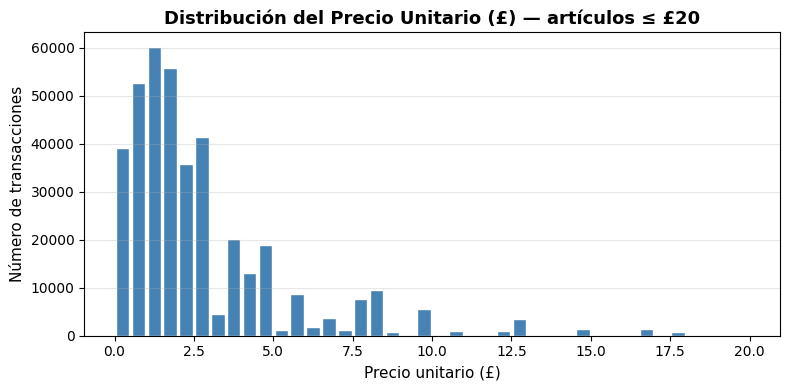

Artículos con precio <= £20: 391,572 (99.7 % del dataset limpio)


In [3]:
import matplotlib.pyplot as plt

# --- Visualización 1: Histograma de distribución de UnitPrice ---
# Filtramos precios <= 20 para mostrar la distribución típica sin outliers extremos
precios = df_limpio[df_limpio['UnitPrice'] <= 20]['UnitPrice']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(precios, bins=40, color='steelblue', edgecolor='white', rwidth=0.85)
ax.set_title('Distribución del Precio Unitario (£) — artículos ≤ £20', fontsize=13, fontweight='bold')
ax.set_xlabel('Precio unitario (£)', fontsize=11)
ax.set_ylabel('Número de transacciones', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Artículos con precio <= £20: {len(precios):,} ({len(precios)/len(df_limpio)*100:.1f} % del dataset limpio)')

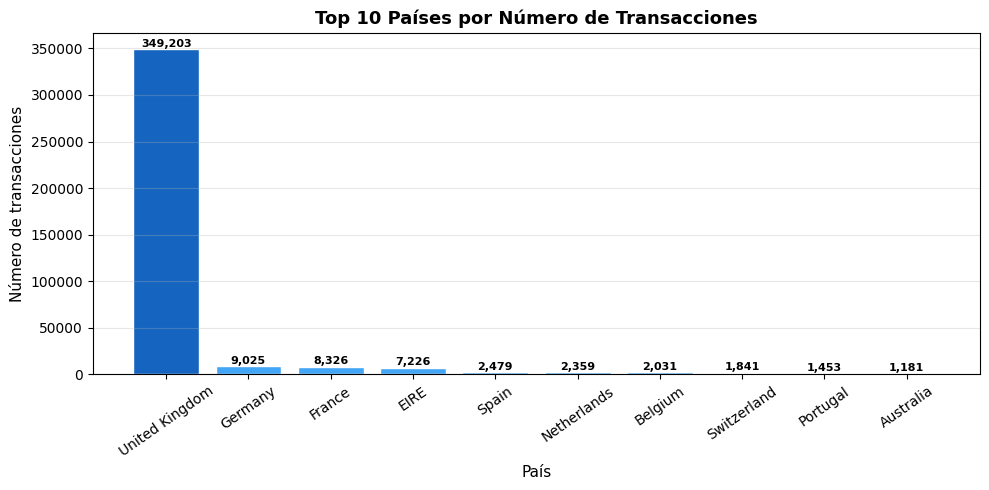


Top 10 países:
Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181


In [4]:
# --- Visualización 2: Gráfico de barras — Top 10 países por número de transacciones ---
top_paises = df_limpio['Country'].value_counts().head(10)

colores = ['#1565C0' if p == 'United Kingdom' else '#42A5F5' for p in top_paises.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top_paises.index, top_paises.values, color=colores, edgecolor='white')
ax.set_title('Top 10 Países por Número de Transacciones', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de transacciones', fontsize=11)
ax.set_xlabel('País', fontsize=11)
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, top_paises.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 200, f'{val:,}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 10 países:')
print(top_paises.to_string())

## 4. Interpretación de Resultados

### Tendencias observadas en el histograma de precios

| Observación | Detalle |
|-------------|--------|
| **Distribución muy sesgada a la derecha** | La gran mayoría de los artículos tienen precio entre £0.50 y £5.00; muy pocos superan £10 |
| **Pico principal entre £1 y £3** | La tienda vende mayoritariamente artículos de bajo costo (regalos y decoración) |
| **Presencia de outliers** | Algunos artículos alcanzan precios de £500–£600 (artículos de alto valor o errores de carga) |

### Tendencias observadas en el gráfico por país

| Observación | Detalle |
|-------------|--------|
| **Dominio absoluto de United Kingdom** | Más del 80 % de las transacciones provienen del Reino Unido, mercado local de la tienda |
| **Mercados secundarios clave** | Alemania, Francia, Irlanda y España lideran el mercado europeo |
| **Oportunidad de internacionalización** | Países como Australia y Países Bajos, aunque en menor volumen, tienen presencia, lo que indica demanda internacional |

### Características del dataset tras la limpieza

- Se eliminaron ~**24.9 %** de filas por falta de `CustomerID` → análisis de comportamiento requiere datos completos
- Las devoluciones (`Quantity < 0`) representan una fracción importante → deben analizarse por separado para calcular tasa de retorno por producto
- El campo `TotalVenta = Quantity × UnitPrice` permite calcular el **Recency-Frequency-Monetary (RFM)** por cliente

